# 🏠 Boston House Price Prediction

**Goal:** Predict the median value of owner-occupied homes (`MEDV`) using various regression techniques.

## Dataset Features
| Feature | Description |
|---------|-------------|
| CRIM | Per capita crime rate by town |
| ZN | Proportion of residential land zoned for lots over 25,000 sq ft |
| INDUS | Proportion of non-retail business acres per town |
| CHAS | Charles River dummy variable (1 if tract bounds river; 0 otherwise) |
| NOX | Nitric oxides concentration (parts per 10 million) |
| RM | Average number of rooms per dwelling |
| AGE | Proportion of owner-occupied units built before 1940 |
| DIS | Weighted distances to five Boston employment centres |
| RAD | Index of accessibility to radial highways |
| TAX | Full-value property-tax rate per $10,000 |
| PTRATIO | Pupil-teacher ratio by town |
| LSTAT | % lower status of the population |
| **MEDV** | **Median value of owner-occupied homes in $1000s (Target)** |

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load & Explore the Data

In [2]:
df = pd.read_csv('Boston.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nFeatures: {list(df.columns)}')
df.head()

Dataset shape: (506, 13)

Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [20]:
print('=== Basic Statistics ===')
desc = df.describe().T
desc['skew'] = df.skew()
desc['kurtosis'] = df.kurtosis()
desc = desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis']]
desc = desc.style.background_gradient(cmap='Reds', subset=['mean', 'std']).format("{:.2f}")
display(desc)

=== Basic Statistics ===


,mean,std,min,25%,50%,75%,max,skew,kurtosis
CRIM,3.61,8.60,0.01,0.08,0.26,3.68,88.98,5.22,37.13
ZN,11.36,23.32,0.00,0.00,0.00,12.50,100.00,2.23,4.03
INDUS,11.14,6.86,0.46,5.19,9.69,18.10,27.74,0.30,-1.23
CHAS,0.07,0.25,0.00,0.00,0.00,0.00,1.00,3.41,9.64
NOX,0.55,0.12,0.39,0.45,0.54,0.62,0.87,0.73,-0.06
RM,6.28,0.70,3.56,5.89,6.21,6.62,8.78,0.40,1.89
AGE,68.57,28.15,2.90,45.02,77.50,94.07,100.00,-0.60,-0.97
DIS,3.80,2.11,1.13,2.10,3.21,5.19,12.13,1.01,0.49
RAD,9.55,8.71,1.00,4.00,5.00,24.00,24.00,1.00,-0.87
TAX,408.24,168.54,187.00,279.00,330.00,666.00,711.00,0.67,-1.14


In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values! ✅')

print('\n=== Data Types ===')
print(df.dtypes)

=== Missing Values ===
No missing values! ✅

=== Data Types ===
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
LSTAT      float64
MEDV       float64
dtype: object


## 3. Exploratory Data Analysis (EDA)

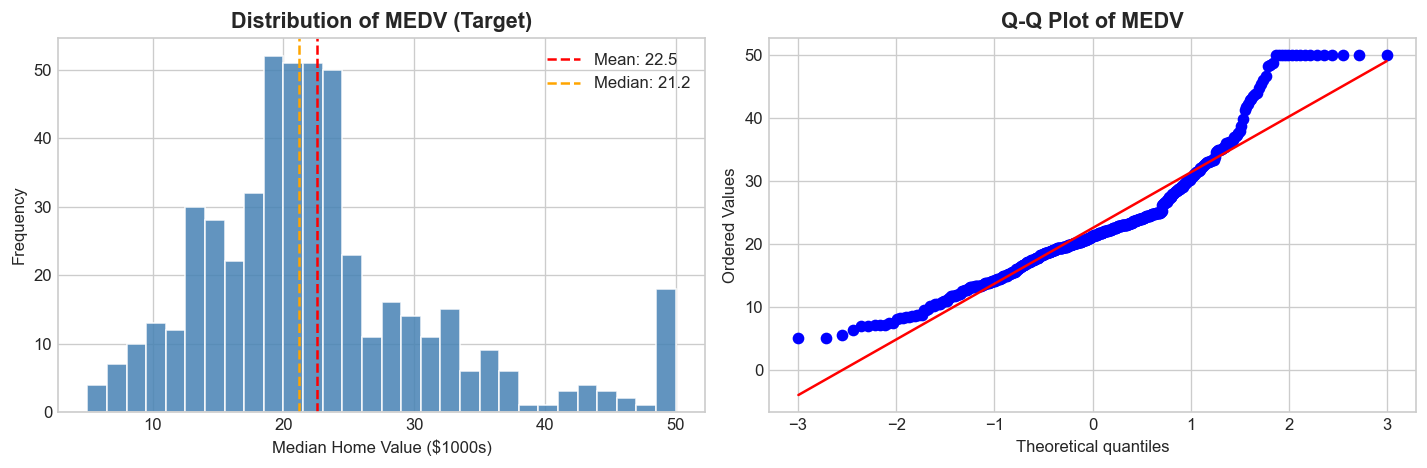

Skewness: 1.108 | Kurtosis: 1.495


In [5]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of MEDV (Target)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median Home Value ($1000s)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['MEDV'].mean(), color='red', linestyle='--', label=f'Mean: {df["MEDV"].mean():.1f}')
axes[0].axvline(df['MEDV'].median(), color='orange', linestyle='--', label=f'Median: {df["MEDV"].median():.1f}')
axes[0].legend()

import scipy.stats as stats
stats.probplot(df['MEDV'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of MEDV', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Skewness: {df["MEDV"].skew():.3f} | Kurtosis: {df["MEDV"].kurtosis():.3f}')

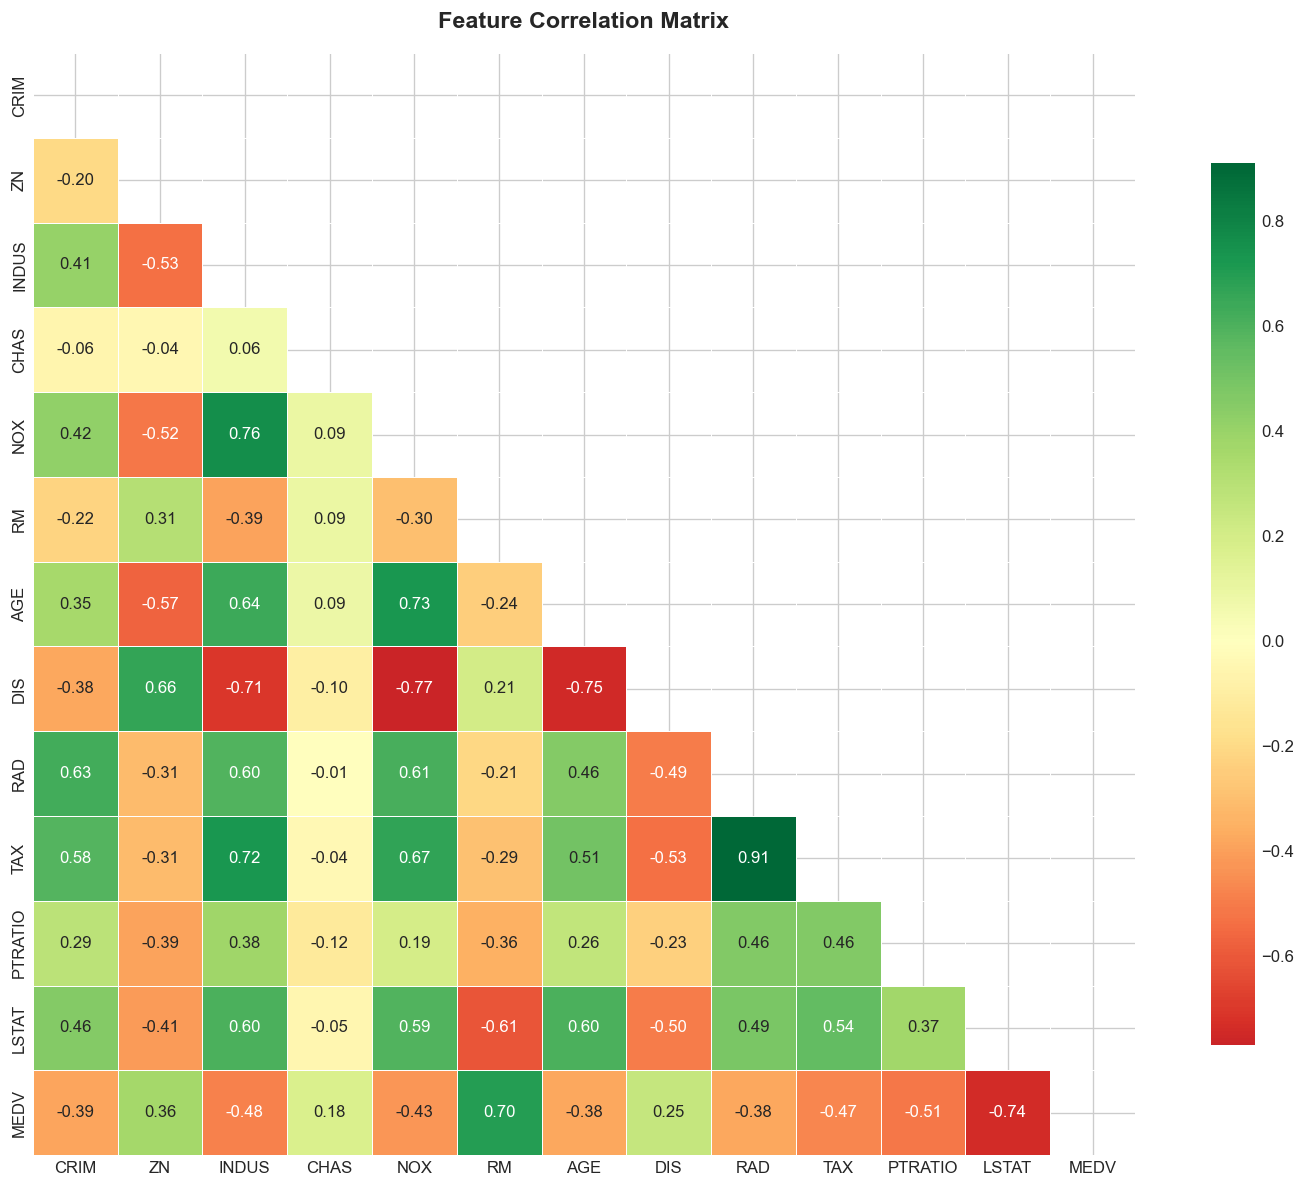

In [6]:
# Correlation heatmap
plt.figure(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

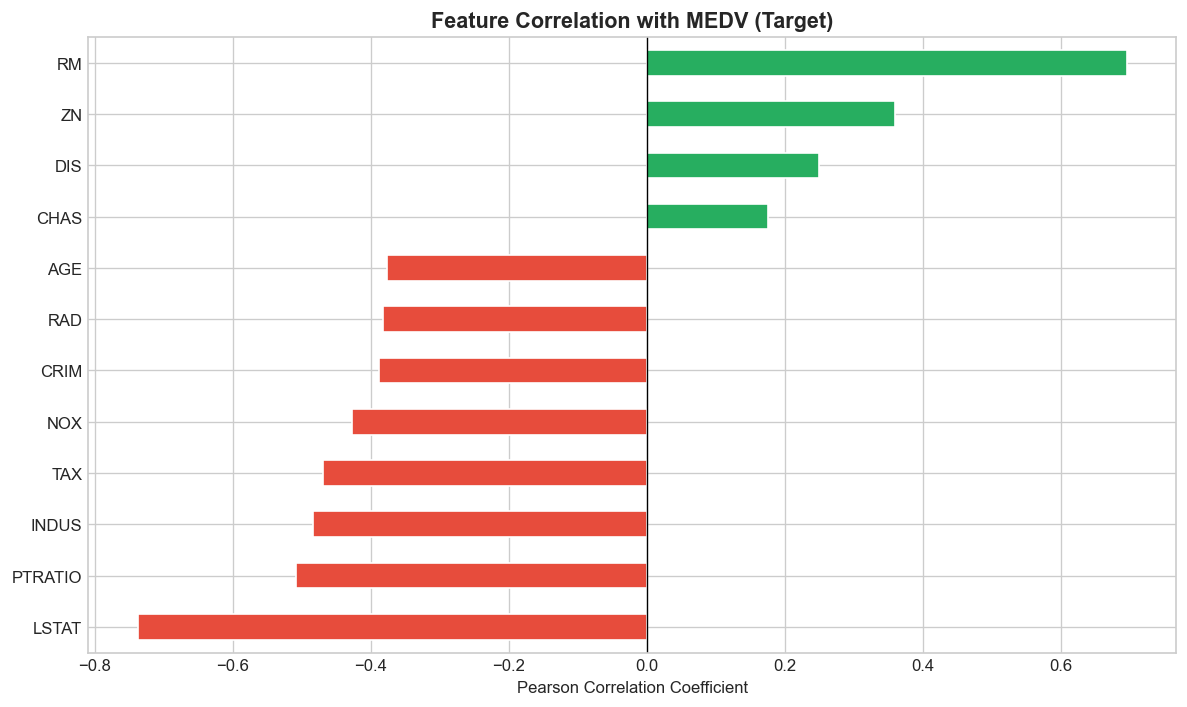


Top positive correlations: ['DIS', 'ZN', 'RM']
Top negative correlations: ['LSTAT', 'PTRATIO', 'INDUS']


In [7]:
# Top correlations with target
target_corr = corr['MEDV'].drop('MEDV').sort_values()
colors = ['#e74c3c' if c < 0 else '#27ae60' for c in target_corr]

plt.figure(figsize=(10, 6))
target_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Correlation with MEDV (Target)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print('\nTop positive correlations:', target_corr.tail(3).index.tolist())
print('Top negative correlations:', target_corr.head(3).index.tolist())

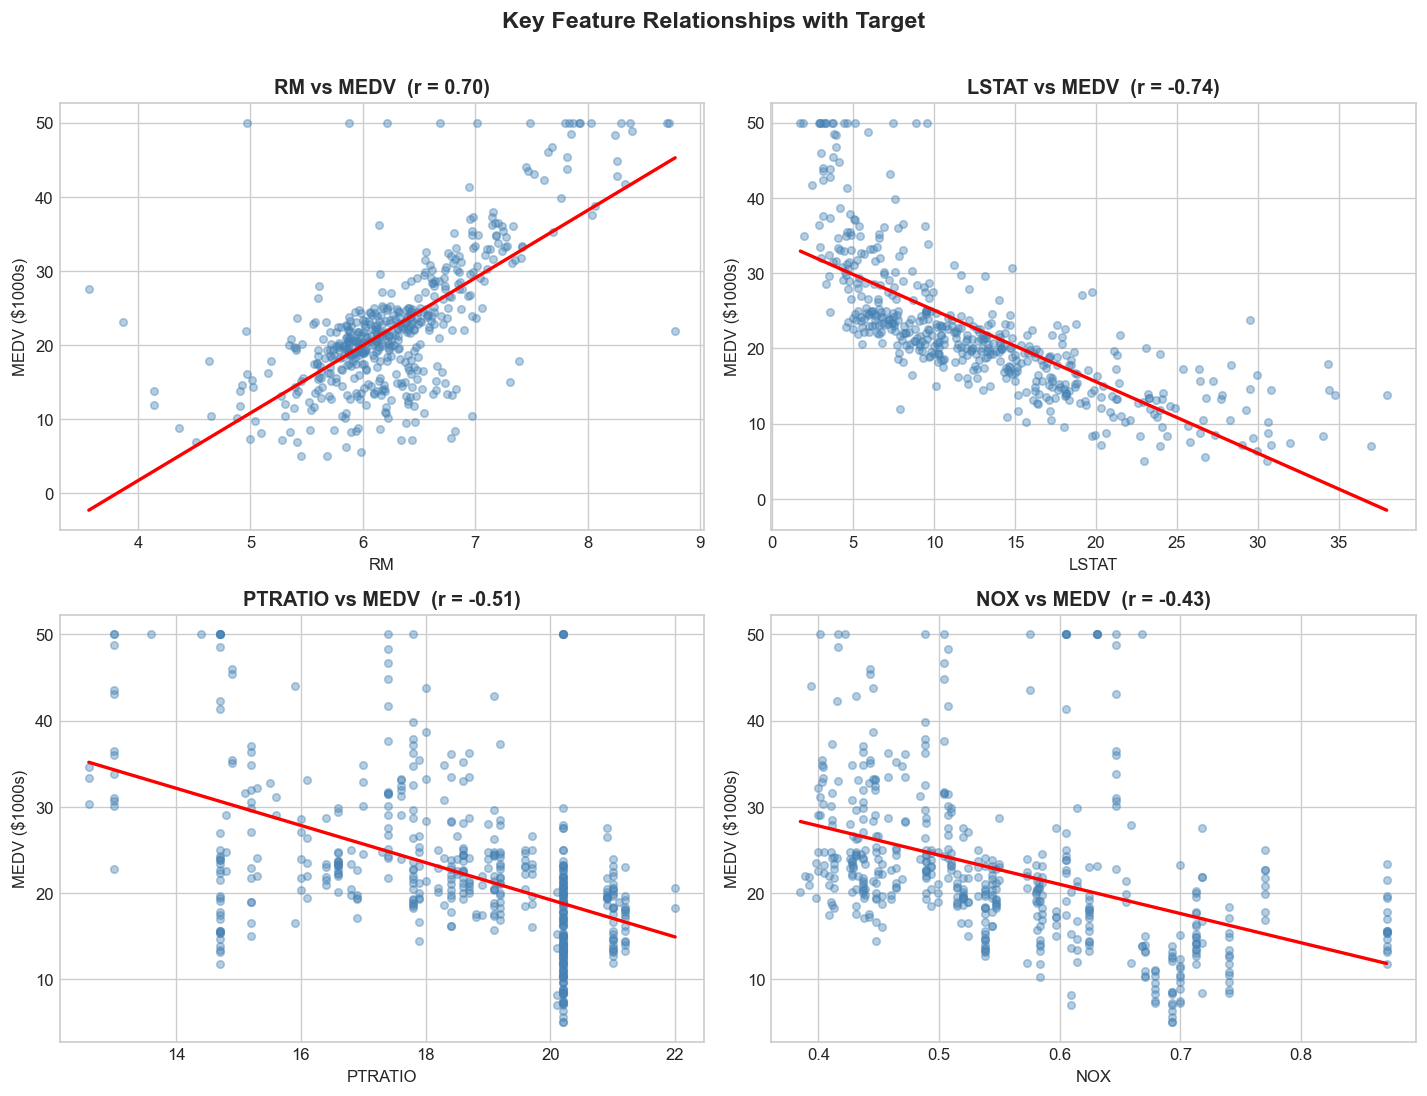

In [8]:
# Key feature scatter plots
key_features = ['RM', 'LSTAT', 'PTRATIO', 'NOX']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feat in zip(axes.flatten(), key_features):
    ax.scatter(df[feat], df['MEDV'], alpha=0.4, s=20, color='steelblue')
    # Regression line
    m, b = np.polyfit(df[feat], df['MEDV'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=2)
    corr_val = df[feat].corr(df['MEDV'])
    ax.set_title(f'{feat} vs MEDV  (r = {corr_val:.2f})', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('MEDV ($1000s)')

plt.suptitle('Key Feature Relationships with Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

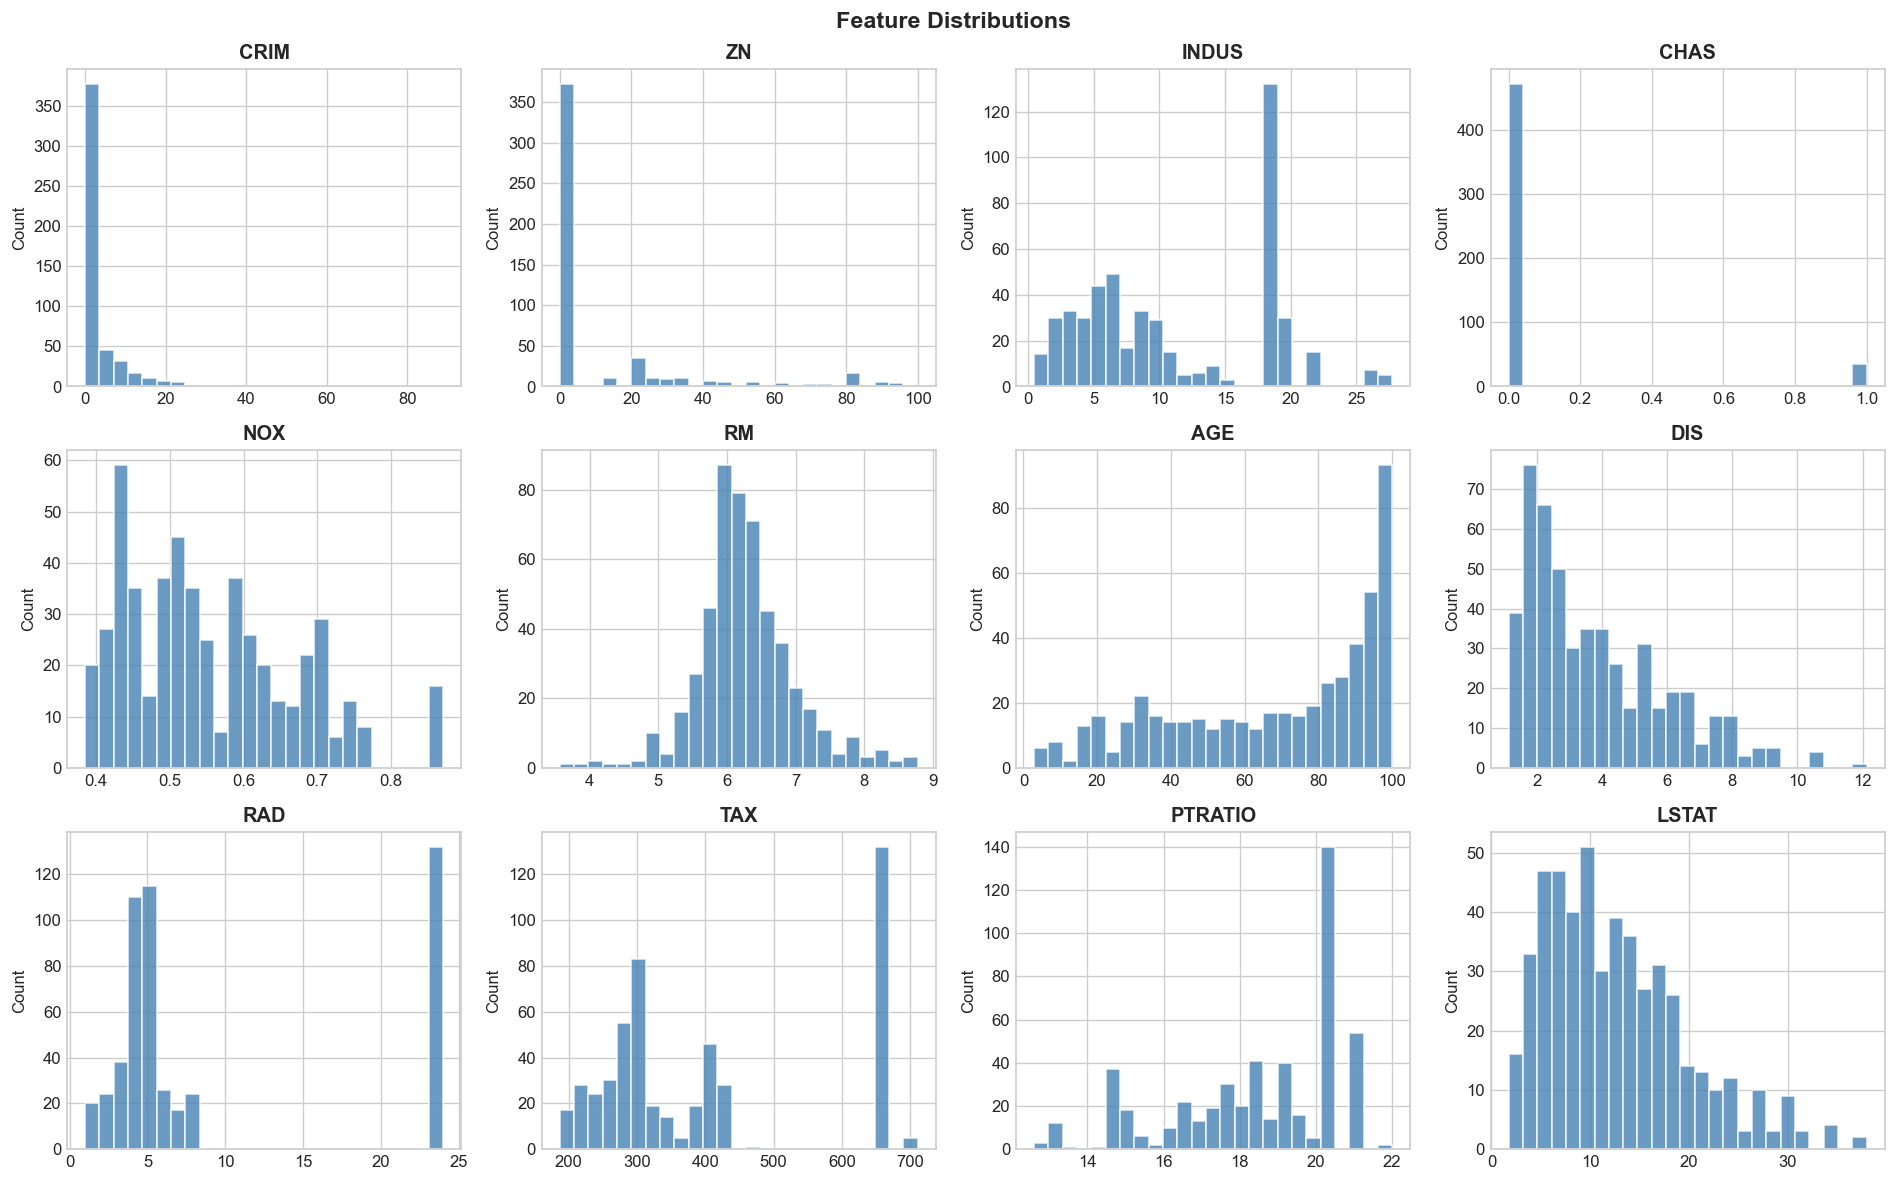

In [9]:
# Feature distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
features = [c for c in df.columns if c != 'MEDV']

for ax, feat in zip(axes.flatten(), features):
    ax.hist(df[feat], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing

In [10]:
# Feature Engineering: add log transform for skewed features
df_eng = df.copy()

skewed_feats = ['CRIM', 'ZN', 'DIS', 'RAD']
for feat in skewed_feats:
    df_eng[f'LOG_{feat}'] = np.log1p(df[feat])
    print(f'{feat} skew: {df[feat].skew():.2f} → log: {df_eng[f"LOG_{feat}"].skew():.2f}')

# Interaction features
df_eng['RM_LSTAT'] = df['RM'] * df['LSTAT']       # room–status interaction
df_eng['NOX_DIS']  = df['NOX'] * df['DIS']         # pollution–distance interaction
df_eng['RM2']      = df['RM'] ** 2                  # quadratic room count

print(f'\nOriginal features: {df.shape[1]}')
print(f'Engineered features: {df_eng.shape[1]}')

CRIM skew: 5.22 → log: 1.27
ZN skew: 2.23 → log: 1.19
DIS skew: 1.01 → log: 0.33
RAD skew: 1.00 → log: 0.53

Original features: 13
Engineered features: 20


In [11]:
# Split and scale
X = df_eng.drop('MEDV', axis=1)
y = df_eng['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set:   {X_train.shape}')
print(f'Test set:       {X_test.shape}')
print(f'Features used:  {X.shape[1]}')

Training set:   (404, 19)
Test set:       (102, 19)
Features used:  19


## 5. Model Training & Evaluation

In [12]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    """Train, predict, and compute metrics."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)
    
    # 5-fold CV RMSE
    cv = cross_val_score(model, X_tr, y_tr, cv=5,
                         scoring='neg_root_mean_squared_error')
    cv_rmse = -cv.mean()
    
    return {
        'Model': name,
        'Test RMSE': round(rmse, 3),
        'Test MAE':  round(mae,  3),
        'Test R²':   round(r2,   3),
        'CV RMSE':   round(cv_rmse, 3),
        '_preds':    preds,
        '_model':    model
    }

results = []

# Linear Regression (scaled)
r = evaluate_model('Linear Regression', LinearRegression(),
                   X_train_sc, y_train, X_test_sc, y_test)
results.append(r)

# Ridge (scaled)
r = evaluate_model('Ridge (α=10)', Ridge(alpha=10),
                   X_train_sc, y_train, X_test_sc, y_test)
results.append(r)

# Lasso (scaled)
r = evaluate_model('Lasso (α=0.1)', Lasso(alpha=0.1),
                   X_train_sc, y_train, X_test_sc, y_test)
results.append(r)

# Random Forest (raw features, tree-based)
r = evaluate_model('Random Forest', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
                   X_train, y_train, X_test, y_test)
results.append(r)

# Gradient Boosting (raw features)
r = evaluate_model('Gradient Boosting', GradientBoostingRegressor(
                       n_estimators=300, learning_rate=0.05,
                       max_depth=4, random_state=RANDOM_STATE),
                   X_train, y_train, X_test, y_test)
results.append(r)

# Summary table
summary = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
summary = summary.sort_values('Test R²', ascending=False).reset_index(drop=True)
summary

,Model,Test RMSE,Test MAE,Test R²,CV RMSE
0,Gradient Boosting,2.519,1.688,0.913,3.659
1,Random Forest,2.910,1.949,0.885,3.830
2,Linear Regression,3.544,2.247,0.829,4.137
3,Ridge (α=10),4.067,2.607,0.774,4.371
4,Lasso (α=0.1),4.273,2.746,0.751,4.423


## 6. Model Comparison Visualizations

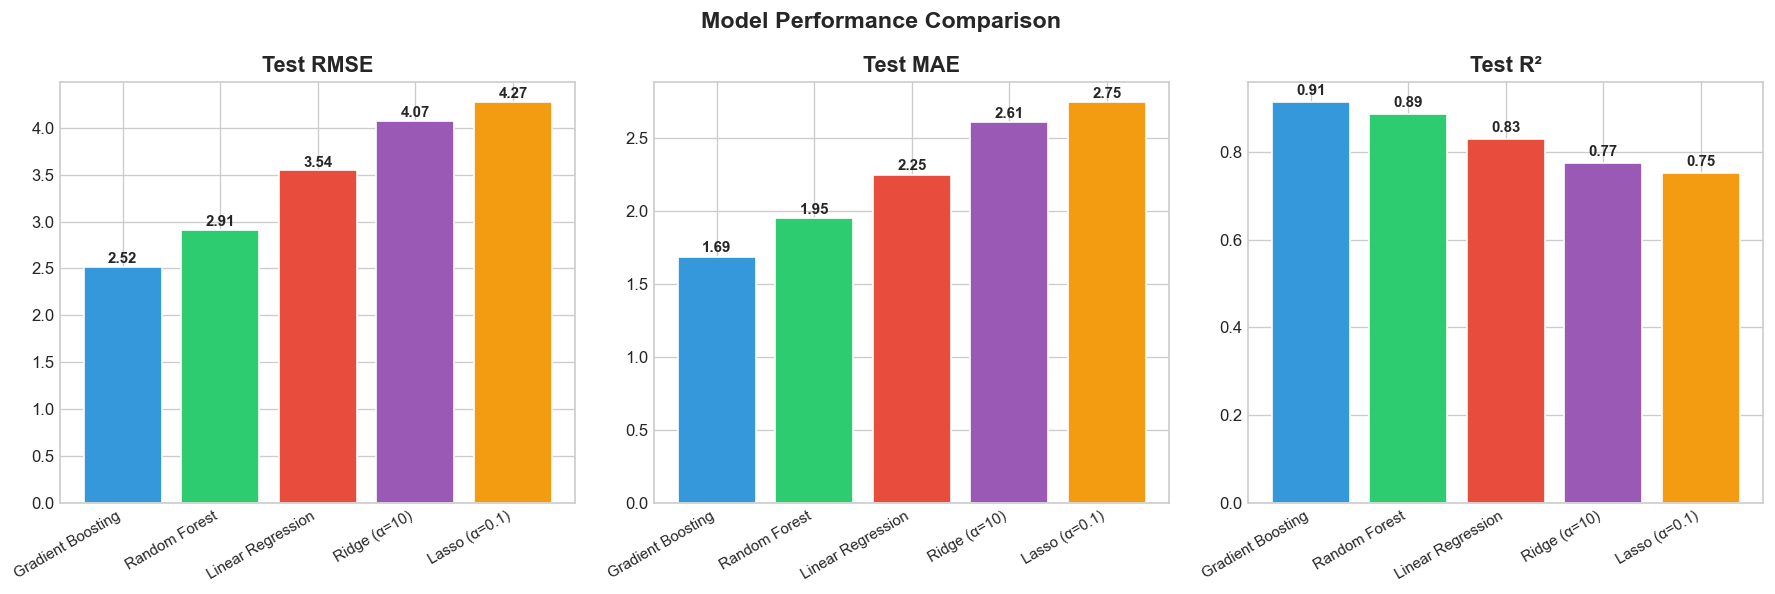

In [13]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_names = summary['Model']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for ax, metric in zip(axes, ['Test RMSE', 'Test MAE', 'Test R²']):
    vals = summary[metric]
    bars = ax.bar(models_names, vals, color=colors[:len(models_names)], edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(models_names, rotation=30, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

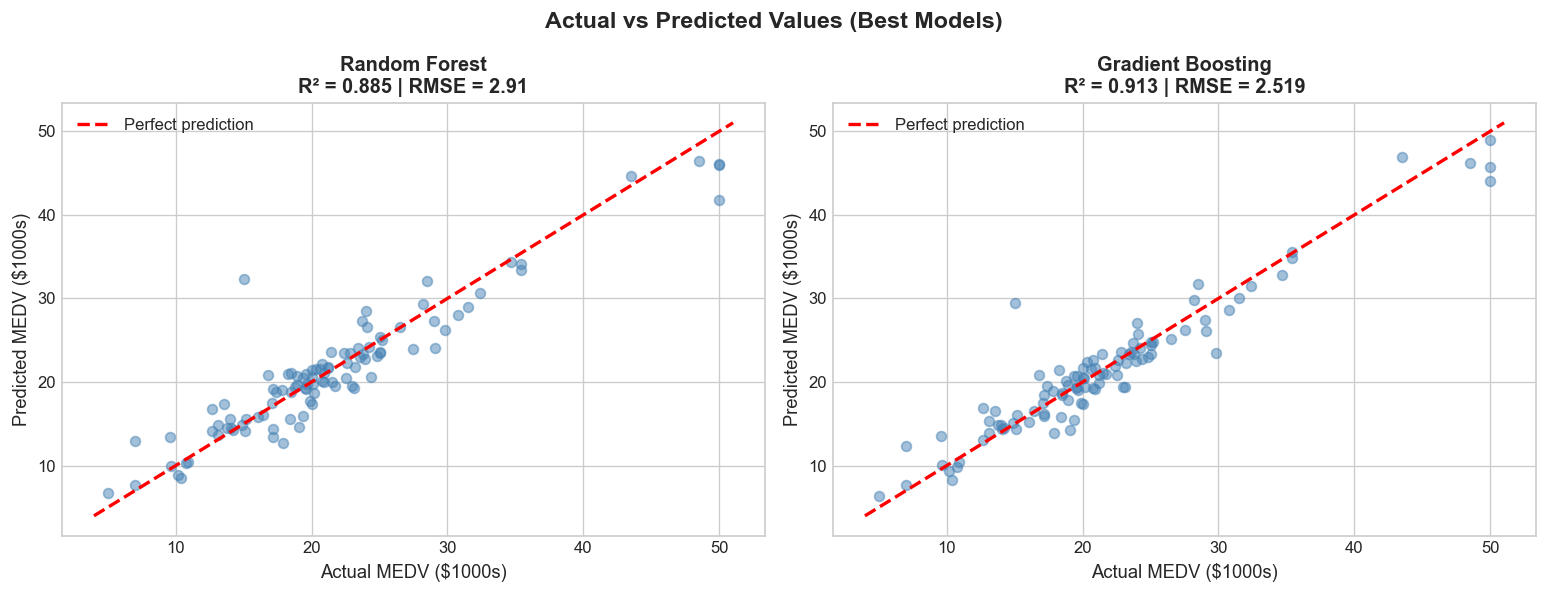

In [14]:
# Actual vs Predicted — best two models
best_models = [r for r in results if r['Model'] in ['Gradient Boosting', 'Random Forest']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, res in zip(axes, best_models):
    preds = res['_preds']
    ax.scatter(y_test, preds, alpha=0.5, s=35, color='steelblue')
    lims = [min(y_test.min(), preds.min()) - 1, max(y_test.max(), preds.max()) + 1]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual MEDV ($1000s)', fontsize=11)
    ax.set_ylabel('Predicted MEDV ($1000s)', fontsize=11)
    ax.set_title(f"{res['Model']}\nR² = {res['Test R²']} | RMSE = {res['Test RMSE']}",
                 fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted Values (Best Models)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

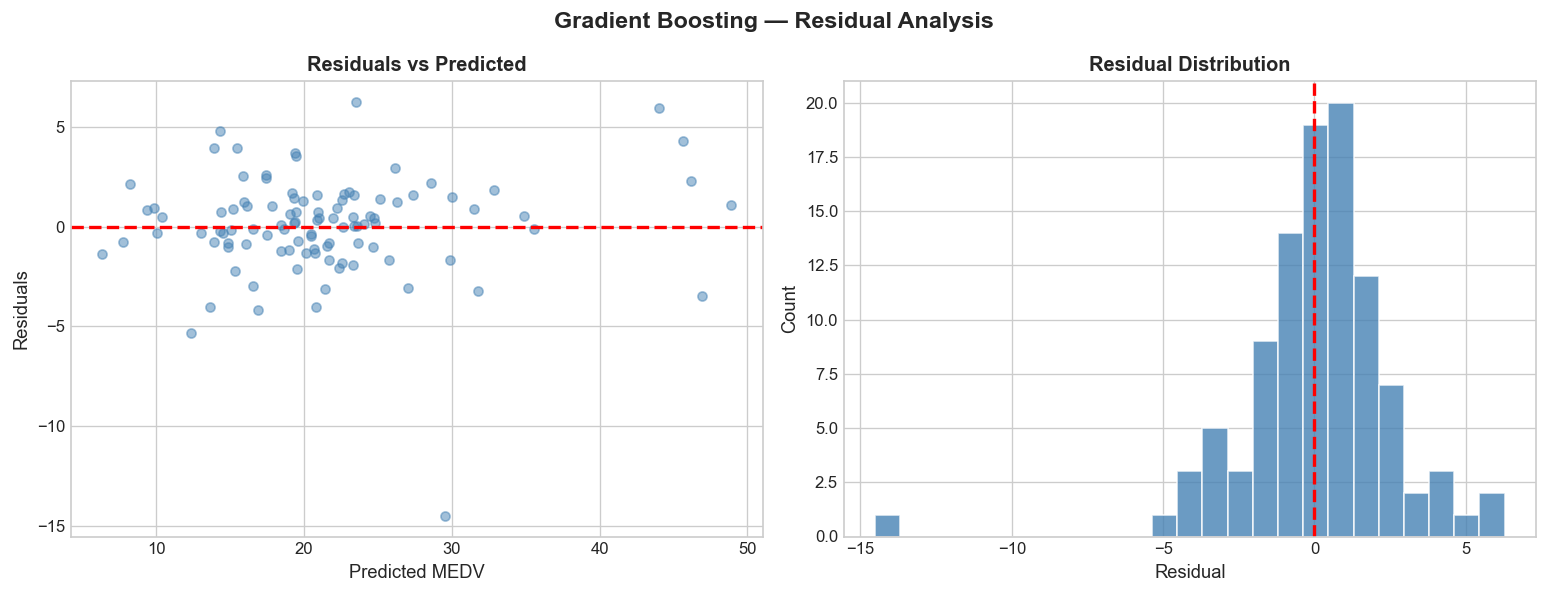

Residuals mean: 0.0823  (ideal ≈ 0)
Residuals std:  2.5301


In [15]:
# Residual analysis — best model (Gradient Boosting)
gb_res = next(r for r in results if r['Model'] == 'Gradient Boosting')
residuals = y_test - gb_res['_preds']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(gb_res['_preds'], residuals, alpha=0.5, s=30, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted MEDV', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Gradient Boosting — Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Residuals mean: {residuals.mean():.4f}  (ideal ≈ 0)')
print(f'Residuals std:  {residuals.std():.4f}')

## 7. Feature Importance

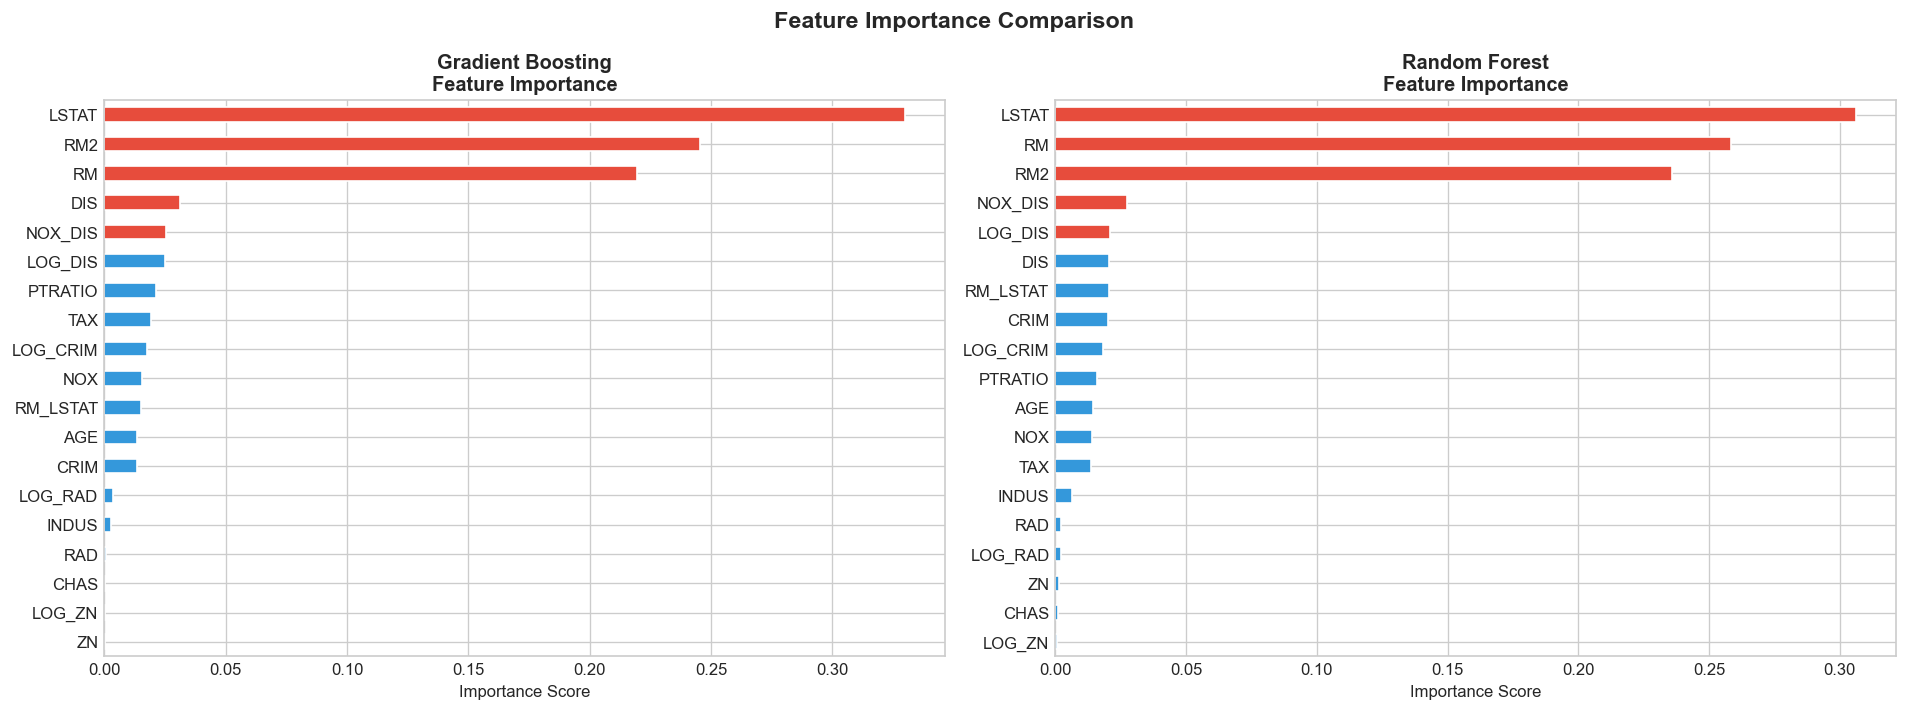

In [16]:
gb_model = next(r['_model'] for r in results if r['Model'] == 'Gradient Boosting')
rf_model = next(r['_model'] for r in results if r['Model'] == 'Random Forest')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title in zip(
    axes,
    [gb_model, rf_model],
    ['Gradient Boosting', 'Random Forest']
):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    colors_imp = ['#e74c3c' if v >= imp.quantile(0.75) else '#3498db' for v in imp]
    imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'{title}\nFeature Importance', fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Final Summary

In [17]:
best = summary.iloc[0]
print('=' * 55)
print('  BOSTON HOUSE PRICE PREDICTION — FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset:       506 samples, 12 original features')
print(f'  Engineered to: {X.shape[1]} features after FE')
print(f'  Train / Test:  {len(X_train)} / {len(X_test)} samples (80/20)')
print()
print(f'  🏆 Best Model:  {best["Model"]}')
print(f'     Test R²:    {best["Test R²"]}   (explains {best["Test R²"]*100:.1f}% of variance)')
print(f'     Test RMSE:  {best["Test RMSE"]} ($1000s)')
print(f'     Test MAE:   {best["Test MAE"]}  ($1000s)')
print(f'     CV RMSE:    {best["CV RMSE"]}   (5-fold)')
print('=' * 55)
print()
print('Key insights:')
print('  • LSTAT (% lower-status pop) and RM (avg rooms) are')
print('    consistently the most predictive features.')
print('  • Tree-based ensembles significantly outperform linear models,')
print('    suggesting non-linear relationships in the data.')
print('  • Feature engineering (log transforms + interactions)')
print('    further boosted linear model performance.')
print()
print('Full leaderboard:')
print(summary[['Model','Test R²','Test RMSE','CV RMSE']].to_string(index=False))

  BOSTON HOUSE PRICE PREDICTION — FINAL SUMMARY
  Dataset:       506 samples, 12 original features
  Engineered to: 19 features after FE
  Train / Test:  404 / 102 samples (80/20)

  🏆 Best Model:  Gradient Boosting
     Test R²:    0.913   (explains 91.3% of variance)
     Test RMSE:  2.519 ($1000s)
     Test MAE:   1.688  ($1000s)
     CV RMSE:    3.659   (5-fold)

Key insights:
  • LSTAT (% lower-status pop) and RM (avg rooms) are
    consistently the most predictive features.
  • Tree-based ensembles significantly outperform linear models,
    suggesting non-linear relationships in the data.
  • Feature engineering (log transforms + interactions)
    further boosted linear model performance.

Full leaderboard:
            Model  Test R²  Test RMSE  CV RMSE
Gradient Boosting    0.913      2.519    3.659
    Random Forest    0.885      2.910    3.830
Linear Regression    0.829      3.544    4.137
     Ridge (α=10)    0.774      4.067    4.371
    Lasso (α=0.1)    0.751      4.273    